In [ ]:
using GLPK, JuMP, Plots

model = Model(GLPK.Optimizer)

# alpha = 1.0; beta = 0.0   # only cost
alpha = 0.5; beta = 0.5   # balanced
# alpha = 0.2; beta = 0.8   # CO2-focused

T = 20      # Time
N = 20     # Anzahl Zeiteinheiten
M = 3
# 1 = Wärmepumpe        heat pump
# 2 = Biomassekessel    biomass boiler
# 3 = Gaskessel         gas boiler
# 4 = Speichertank      thermal storage discharge

# cost c; sustainability s; capacity m
c = [25, 30, 80]         # COST              - €/MWh
s = [30, 40, 200]        # SUSTAINABILITY    - kg_CO2/MWh
m = [150, 150, 150]      # max. MW

"""Demand darf 370 nicht überschreiten"""
# d = [370, 200, 230, 270, 300, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190]   # MW 
d = [370, 200, 230, 270, 450, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190]   # MW 

# Steigung - Steuerungsspontanität
k_heat = [60,20,100]        # MW/t - max heat-up speed
k_cool = [60,10,100]        # MW/t - max cool-down speed

#thermal storage
E_maxCharge = 60
E_maxDischarge = 60
E_max = 150
E_start = 100
eff_charge = 1.0
eff_discharge = 1.0

@variable(model, E[1:N] >= 0)
@variable(model, charge[1:N] >= 0)
@variable(model, discharge[1:N] >= 0)

@variable(model, x[1:3,1:N] >= 0)

# KOSTEN minimieren
@objective( model, Min, alpha * sum( sum(x[j,t]*c[j] for t=1:N) for j=1:M) + 
                        beta * sum( sum(x[j,t]*s[j] for t=1:N) for j=1:M))
# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model, [j=1:M,t=1:N], x[j,t] <= m[j])
# DEMAND hast to be met     -    für alle Zeitpunkte i
# @constraint(model, [t=1:N],   sum( x[j,t] for j=1:M) >= d[t]    )

# heating speed
@constraint(model, [j=1:M, t=2:N],  x[j,t] - x[j,t-1] <= k_heat[j])
@constraint(model, [j=1:M, t=2:N],  x[j,t-1] - x[j,t] <= k_cool[j])

# SPEICHER
@constraint(model, [t=1:N], charge[t]    <= E_maxCharge)                                 # charging-speed
@constraint(model, [t=1:N], discharge[t] <= E_maxDischarge)
@constraint(model, [t=1:N], E[t]         <= E_max)                                       # storage-capazity
@constraint(model, [t=1:N], sum( x[i,t] for i=1:M) + discharge[t] == d[t] + charge[t])      # heat-equality

@constraint(model, [t=2:N], E[t] == E[t-1] + eff_charge * charge[t] - 1/eff_discharge * discharge[t])          # keep track of storage
@constraint(model, E[1] == E_start + eff_charge * charge[1] - 1/eff_discharge * discharge[1])
@constraint(model, E[N] == E_start)
optimize!(model)

println("Solver status: ", termination_status(model))
println("Solution status: ", primal_status(model))
## Printing the solution
println("Objective value = ", objective_value(model)) 


cost = 0
CO2 = 0

for j=1:M
    for t=1:N
        print(value(x[j,t]),"\t")
        cost += value(x[j,t])*c[j]
        CO2 += value(x[j,t])*s[j]
    end
    println(".")
end

println("\nEnergie in storage:")
for t=1:N
    print(value(E[t]),"\t")
end

# for j=1:M
#     for t=1:N
#         cost += value(x[j,t])*c[j]
#         CO2 += value(x[j,t])*s[j]
#     end
# end
println("\nCost in €: ",cost)
println("CO2 in Kg: ", CO2)

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 185909.1765909556
150.0	119.99999999999996	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	120.0	60.0	0.0	60.0	120.0	150.0	150.0	150.0	150.0	150.0	.
150.0	140.0	130.0	133.7037037037037	139.99999999999997	129.99999999999997	119.99999999999999	109.99999999999999	99.99999999999999	89.99999999999999	79.99999999999999	69.99999999999999	59.999999999999986	79.99999999999999	99.99999999999999	120.0	110.0	100.0	106.0220994475138	96.0220994475138	.
10.0	0.0	0.0	0.0	100.00000000000001	0.0	0.0	0.0	60.000000000000036	0.0	0.0	10.000000000000028	0.0	70.00000000000003	20.0	9.70000000000002	0.0	0.0	0.0	0.0	.

Energie in storage:
33.33333333333331	87.33333333333329	132.3333333333333	144.66666666666663	77.99999999999997	77.99999999999999	104.99999999999996	149.99999999999994	83.3333333333333	128.3333333333333	146.3333333333333	79.66666666666663	133.66666666666663	66.99999999999999	0.33333333333331	0.0	18.0	54.0	49.58011049723757	100

INTERPRET THE TWO GRAPHS, AS FOLLOWS:
MovementStorage > 0 <=> storage discharges <=> Energy decreasing
MovementStorage < 0 <=> storage charges  <=> Energy increasing

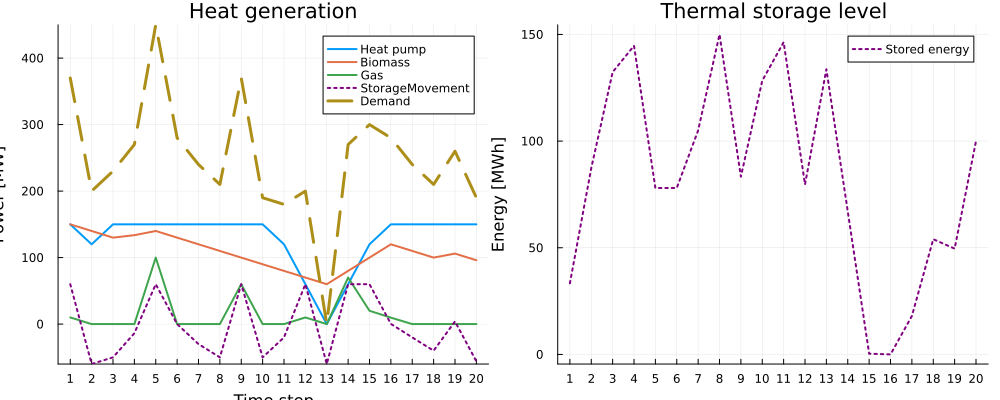

In [ ]:
MovementStorage = value.(discharge) - value.(charge)
InStorage   = value.(E)
ymax = maximum(d)
ymin = minimum([minimum(MovementStorage),0])

p_power = plot(1:N,[value.(x[j,:]) for j in 1:3],labels=["Heat pump" "Biomass" "Gas"],xlabel="Time step",ylabel="Power [MW]",lw=2,title="Heat generation",ylim=(ymin,ymax), xticks=1:N, grid=true)
plot!(p_power, 1:N, MovementStorage,label="StorageMovement",lw=2,linestyle=:dot,color=:purple)
plot!(p_power, 1:N, d,label="Demand",lw=3,linestyle=:dash)

p_storage = plot(1:N,InStorage,label="Stored energy",ylabel="Energy [MWh]",lw=2,title="Thermal storage level",linestyle=:dot,color=:purple, xticks=1:N,grid=true)   #,ylim=(ymin,ymax)

p = plot(p_power,p_storage,layout=(1,2),size=(1000,400))
print("INTERPRET THE TWO GRAPHS, AS FOLLOWS:
MovementStorage > 0 <=> storage discharges <=> Energy decreasing
MovementStorage < 0 <=> storage charges  <=> Energy increasing"
)
display(p)


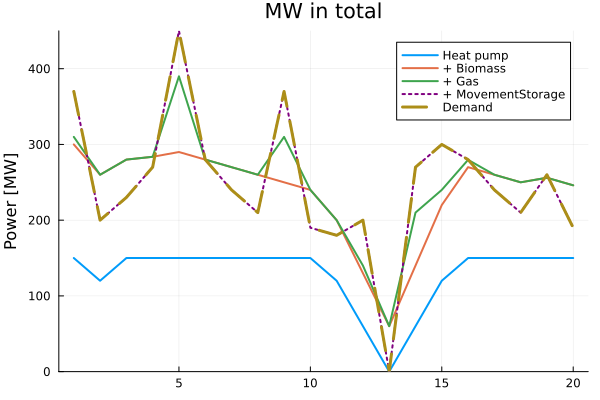

In [23]:
x_result = value.(x)

hp  = x_result[1,:]
bio = hp .+ x_result[2,:]
gas = bio .+ x_result[3,:]
total = gas .+ MovementStorage[:]
# tes = gas .+ x_result[4,:]

p1 = plot(1:N, hp, label="Heat pump", lw=2,title="MW in total",ylim=(0,ymax))
plot!(p1, 1:N, bio, label="+ Biomass", lw=2)
plot!(p1, 1:N, gas, label="+ Gas", lw=2)
plot!(p1, 1:N, total, label="+ MovementStorage", lw=2, linestyle=:dot,color=:purple)
plot!(p1, 1:N, d, label="Demand", lw=3, linestyle=:dash)

# xlabel!(p1, "Time step")
ylabel!(p1, "Power [MW]")
display(p1)